# **Steam Game Review Sentiment Analysis Using Word2Vec, Machine Learning and Artificial Neural Network**

## **Problem Statement**

The rapid growth of online gaming platforms has resulted in a large volume of user-generated reviews. These reviews contain valuable information about players' opinions, experiences, and satisfaction with games. However, manually analyzing thousands of reviews is time-consuming and inefficient.

## **Objective**  
The objective of this project is to develop an NLP-based sentiment analysis system that automatically classifies Steam game reviews into positive or negative sentiment. The project will use Word2Vec/FastText to convert textual data into numerical feature representations and will compare multiple Machine Learning classification algorithms with an Artificial Neural Network (ANN).

The performance of the models will be evaluated using multiple evaluation metrics, and their strengths, weaknesses, and behavior will be analyzed to determine the most appropriate model for the given sentiment-analysis problem.

## **Dataset**  
The dataset is taken from Kaggle website.  
Link: https://www.kaggle.com/datasets/akashunikaggle/steam-game-reviews-of-743-games

### **Importing all Necessary Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
import re
import nltk 
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Downloading Required NLKT Resources
nltk.download("punkt")
nltk.download("punkt_tabs")
nltk.download("stopwords")
nltk.download("wordnet")

from sklearn.model_selection import train_test_split
from gensim.models import FastText , Word2Vec
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow import keras
from tensorflow.keras import layers
import optuna
from tensorflow.keras.optimizers import SGD, Adam
import time as t

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Soro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading punkt_tabs: Package 'punkt_tabs' not found
[nltk_data]     in index
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Soro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Soro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### **Loading the Dataset**

In [3]:
steam_review_df = pd.read_csv("./dataset/game_reviews.csv")
steam_review_df.head()

,appid,review,word_count,voted_up,votes_up,votes_funny,timestamp_created,author_playtime_forever,name,price,release_date
0,1938090,I really loved the game but itll take you a lo...,26,True,0,0,1757864825,1485,Call of Duty: Modern Warfare II,6999,NaN
1,1938090,i cant join the game for some reason,8,False,0,0,1757864289,346,Call of Duty: Modern Warfare II,6999,NaN
2,1938090,these new games are just living in the MASSIVE...,133,False,0,0,1757861908,2131,Call of Duty: Modern Warfare II,6999,NaN
3,1938090,Its fun of course you have cheaters but beside...,25,True,0,0,1757854957,344,Call of Duty: Modern Warfare II,6999,NaN
4,1938090,I play this game as a casual player on PC. I h...,39,False,0,1,1757846859,1746,Call of Duty: Modern Warfare II,6999,NaN


# **1. Data Understanding And EDA**

## **A. Dataset Analysis**

### **A-1: Shape of the Dataset**

In [4]:
print("Shape of the Dataset:")
print("No. of Rows:", steam_review_df.shape[0])
print("No. of Columns:", steam_review_df.shape[1])

Shape of the Dataset:
No. of Rows: 730945
No. of Columns: 11


### **A-2: Datatypes of Each Columns**

In [5]:
print("Datatypes of Each Columns:\n")
print(steam_review_df.dtypes)

Datatypes of Each Columns:

appid                        int64
review                      object
word_count                   int64
voted_up                      bool
votes_up                     int64
votes_funny                  int64
timestamp_created            int64
author_playtime_forever      int64
name                        object
price                        int64
release_date               float64
dtype: object


**Observations:**  
- All the Datatypes are corrects for our dataset.
- No further changes required.

### **A-3: Checking the Overall Information of Dataset**

In [6]:
steam_review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730945 entries, 0 to 730944
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   appid                    730945 non-null  int64  
 1   review                   730945 non-null  object 
 2   word_count               730945 non-null  int64  
 3   voted_up                 730945 non-null  bool   
 4   votes_up                 730945 non-null  int64  
 5   votes_funny              730945 non-null  int64  
 6   timestamp_created        730945 non-null  int64  
 7   author_playtime_forever  730945 non-null  int64  
 8   name                     730945 non-null  object 
 9   price                    730945 non-null  int64  
 10  release_date             0 non-null       float64
dtypes: bool(1), float64(1), int64(7), object(2)
memory usage: 56.5+ MB


**Observations:**
- There is no missing values for all the columns except `release_date`
- We will drop `release_date` column because this column contains only NaN values which is no use to us.

### **A-4: Null Values Analysis**

In [7]:
print("Null Value Analysis:\n")
print(steam_review_df.isna().sum())

Null Value Analysis:

appid                           0
review                          0
word_count                      0
voted_up                        0
votes_up                        0
votes_funny                     0
timestamp_created               0
author_playtime_forever         0
name                            0
price                           0
release_date               730945
dtype: int64


### **A-5: Duplicatie Values Analysis**

In [8]:
print("Duplicated Value Count Before Removing:",steam_review_df.duplicated().sum())
print("\nDuplicated Values:")
steam_review_df[steam_review_df.duplicated()]

Duplicated Value Count Before Removing: 2

Duplicated Values:


,appid,review,word_count,voted_up,votes_up,votes_funny,timestamp_created,author_playtime_forever,name,price,release_date
491630,9340,well its a great game the only thing is when i...,41,False,2,0,1400141014,2326,Company of Heroes: Opposing Fronts,1999,NaN
491632,9340,well its a great game the only thing is when i...,41,False,0,0,1400141014,2326,Company of Heroes: Opposing Fronts,1999,NaN


**We will drop these Duplicate values**

In [9]:
steam_review_df.drop_duplicates(inplace=True)

In [10]:
print("Duplicated Value Count After Removing:",steam_review_df.duplicated().sum())

Duplicated Value Count After Removing: 0


### **A-6: Unique Value Analysis**

In [11]:
print("Unique Values Analysis:\n")
print("Unique Reviews for `review` Column:", steam_review_df['review'].nunique())
print("Unique Value for `voted_up` Column:", steam_review_df['voted_up'].nunique())

print("Unique Words for `voted_up`:",steam_review_df['voted_up'].unique())


Unique Values Analysis:

Unique Reviews for `review` Column: 721521
Unique Value for `voted_up` Column: 2
Unique Words for `voted_up`: [ True False]


### **A-7: Class Distributions for Target Variable**

In [12]:
print("`voted_up` column Distribution:")
print(steam_review_df['voted_up'].value_counts(normalize=True)*100)

`voted_up` column Distribution:
voted_up
True     81.773408
False    18.226592
Name: proportion, dtype: float64


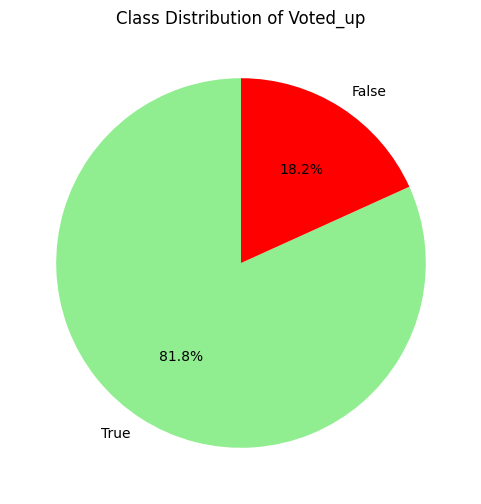

In [13]:
# 1. Get the class counts
values = steam_review_df['voted_up'].value_counts()

# 2. Set up the figure size (optional, makes it look cleaner)
plt.figure(figsize=(6, 6))

# 3. Create the pie chart
plt.pie(
    values, 
    labels=values.index, 
    autopct='%1.1f%%',          
    startangle=90,              
    colors=['lightgreen','red'] 
)

# 4. Set title and display
plt.title("Class Distribution of Voted_up")
plt.show()


**Observations**

- Dominant Class: True (81.77%)
- Minority Class: False (18.23%)
- Class imbalance is heavily present. 


### **A-8: Dropping Unnecessay Columns**

In [14]:
print("All columns before removing:\n",steam_review_df.columns)

All columns before removing:
 Index(['appid', 'review', 'word_count', 'voted_up', 'votes_up', 'votes_funny',
       'timestamp_created', 'author_playtime_forever', 'name', 'price',
       'release_date'],
      dtype='object')


In [15]:
steam_review_df.head(1)

,appid,review,word_count,voted_up,votes_up,votes_funny,timestamp_created,author_playtime_forever,name,price,release_date
0,1938090,I really loved the game but itll take you a lo...,26,True,0,0,1757864825,1485,Call of Duty: Modern Warfare II,6999,NaN


In [16]:
steam_review_df.drop(['votes_funny','timestamp_created','release_date'],axis=1,inplace=True)

In [17]:
print("All Columns after Dropping unnceessary Columns:\n",steam_review_df.columns)

All Columns after Dropping unnceessary Columns:
 Index(['appid', 'review', 'word_count', 'voted_up', 'votes_up',
       'author_playtime_forever', 'name', 'price'],
      dtype='object')


## **B. Text Analysis**

### **B-1: Number of Characters per Text**

In [18]:
steam_review_df['text_char_length'] = steam_review_df['review'].apply(len)

# Checking Few Values
steam_review_df[['review', 'text_char_length']].head(10)


,review,text_char_length
0,I really loved the game but itll take you a lo...,124
1,i cant join the game for some reason,36
2,these new games are just living in the MASSIVE...,741
3,Its fun of course you have cheaters but beside...,121
4,I play this game as a casual player on PC. I h...,202
5,shit game i downloaded 120 gb for nothing to b...,63
6,the gameplay is super fun but everything else ...,273
7,Its very fun but makes your DAMN computer lag\r\n,47
8,dont you dare click the download button\r\n,41
9,i dont get why people hate bo6 or warzone so m...,169


In [19]:
print("Statistical Values for Character Length:")
steam_review_df['text_char_length'].describe()

Statistical Values for Character Length:


count    730943.000000
mean        318.605852
std         637.188279
min          11.000000
25%          57.000000
50%         116.000000
75%         294.000000
max        8000.000000
Name: text_char_length, dtype: float64

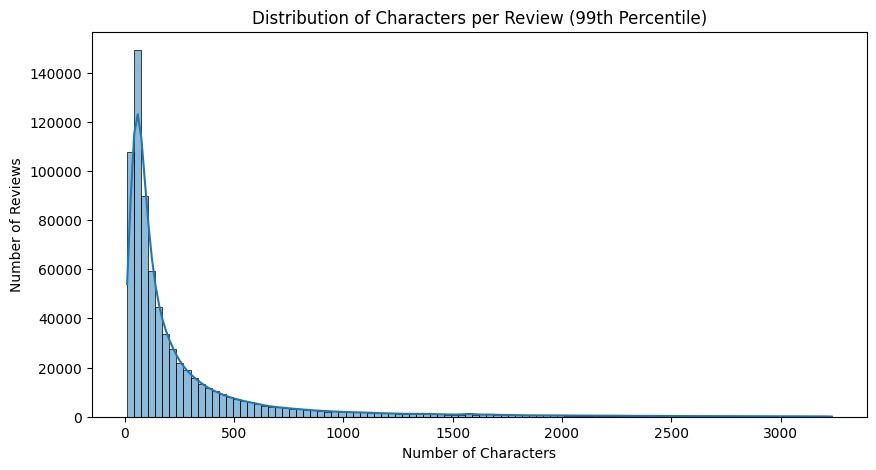

In [20]:
limit = steam_review_df['text_char_length'].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(
    steam_review_df[steam_review_df['text_char_length'] <= limit]['text_char_length'],
    bins=100, kde=True
)

plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Characters per Review (99th Percentile)")

plt.show()

**Observations:**  
- The distribution of characters per review is highly right-skewed. 
- Most reviews are relatively short and contain fewer than 500 characters, while a small number of reviews are considerably longer, resulting in a long right tail. This indicates substantial variation in review length within the dataset.

### **B-2: Number of Words Per Text**

In [21]:
steam_review_df['word_count'].describe()


count    730943.000000
mean         57.174685
std         111.375803
min           6.000000
25%          11.000000
50%          22.000000
75%          53.000000
max        2667.000000
Name: word_count, dtype: float64

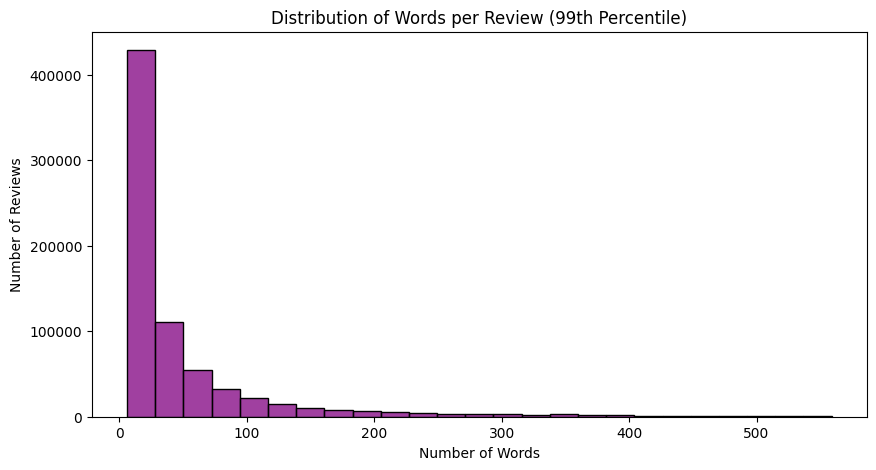

In [22]:

limit = steam_review_df['word_count'].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(
    steam_review_df[steam_review_df['word_count'] <= limit]['word_count'],
    bins=25, color="purple"
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Words per Review (99th Percentile)")

plt.show()

**Observations:**

- Most reviews contain fewer than 50 words.
- The number of reviews decreases rapidly as word count increases.
- There is a long right tail, with some reviews containing more than 500 words.
- Most users write short reviews, while only a small portion provide detailed reviews.
- The dataset therefore contains considerable variation in review length.

### **B-3: Average Text Length**

In [23]:
average_characters = steam_review_df['text_char_length'].mean()
average_words = steam_review_df['word_count'].mean()

print("Average characters per review:", average_characters.round(3))
print("Average words per review:", average_words.round(3))

Average characters per review: 318.606
Average words per review: 57.175


### **B-4: Minimum and maximum text length**

In [24]:
print("Minimum Text Length:", min(steam_review_df['text_char_length']))
print("Maximum Text Length:", max(steam_review_df['text_char_length']))

Minimum Text Length: 11
Maximum Text Length: 8000


### **B-5: Most Frequent Words**

In [25]:
all_words = []
stop_words = set(stopwords.words("english"))

for text in steam_review_df['review'].dropna():
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    words = [word for word in words if word not in stop_words]
    all_words.extend(words)

word_counts = Counter(all_words)

top_words = word_counts.most_common(10)

print("Most Frequent Words:\n")
for word, count in top_words:
    print(f"{word}: {count}")

Most Frequent Words:

game: 924170
like: 220728
good: 185790
fun: 174367
play: 173141
one: 152303
get: 131620
time: 130061
story: 129778
games: 128168


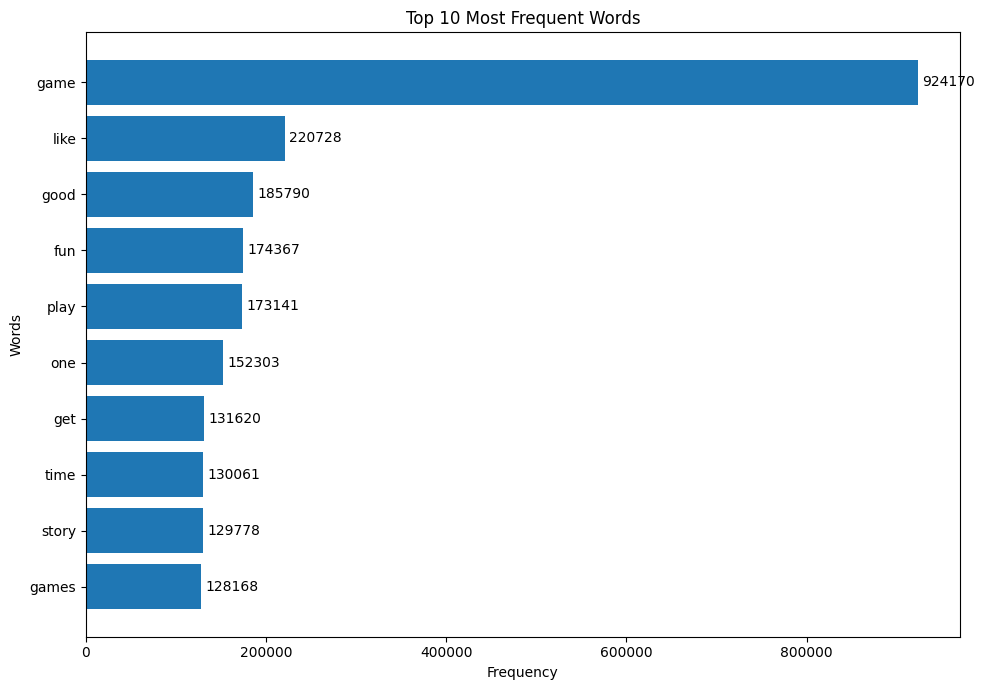

In [26]:
top_words = word_counts.most_common(10)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 7))

bars = plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 10 Most Frequent Words")

# Add frequency labels
plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

**Observations:**
- The most frequent words are mainly related to gameplay and user experience.
- “Game” is the most frequently occurring word, followed by words such as “like”, “good”, “fun”, and “play”. 
- This indicates that Steam users commonly discuss gameplay, enjoyment, and their overall experience when writing reviews.

# **C. Text Preprocessing**

### **C.1 Creating `cleaning_text` Function for cleaning the data**

In [27]:
stop_words = set(stopwords.words("english"))

negations = {"not", "no", "never", "don't", "can't", "won't", "didn't", "isn't"}
stop_words.difference_update(negations)

lemmetizer = WordNetLemmatizer()

def cleaning_text(text):
    # Converting to Lowercase
    text = text.lower()

    # Removing the links
    text = re.sub(r"http\S+|www\S+","",text)

    # Removing the Tags
    text = re.sub(r"<.*?>","",text)

    # Including Letters only
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Tokenization
    words = text.split()

    # Stopwords removal
    words = [word for word in words if word not in stop_words]

    # Applying Lemmetization
    words = [lemmetizer.lemmatize(word) for word in words]

    return words

**Note:**

Words to skip: {"not", "no", "never", "don't", "can't", "won't", "didn't", "isn't"} 

Excluding these words from the stopwords because for sentimental analysis,  
removing these words may affect the word relationships between them.

For Ex: "This Game is not good"  
If we remove the stopwords: {this , is, not} then,  
vocab: [game, good] ----> Here the word relationship is different from our initial statement,
                          here Sentiment is Positive.

### **C.2 Applying `cleaning_text` function to our `review` column**

In [28]:
steam_review_df["tokenized_reviews"] = steam_review_df['review'].apply(cleaning_text)

In [29]:
steam_review_df.head(10)

,appid,review,word_count,voted_up,votes_up,author_playtime_forever,name,price,text_char_length,tokenized_reviews
0,1938090,I really loved the game but itll take you a lo...,26,True,0,1485,Call of Duty: Modern Warfare II,6999,124,"[really, loved, game, itll, take, long, time, ..."
1,1938090,i cant join the game for some reason,8,False,0,346,Call of Duty: Modern Warfare II,6999,36,"[cant, join, game, reason]"
2,1938090,these new games are just living in the MASSIVE...,133,False,0,2131,Call of Duty: Modern Warfare II,6999,741,"[new, game, living, massive, shadow, black, op..."
3,1938090,Its fun of course you have cheaters but beside...,25,True,0,344,Call of Duty: Modern Warfare II,6999,121,"[fun, course, cheater, besides, game, ment, fu..."
4,1938090,I play this game as a casual player on PC. I h...,39,False,0,1746,Call of Duty: Modern Warfare II,6999,202,"[play, game, casual, player, pc, no, mod, hack..."
5,1938090,shit game i downloaded 120 gb for nothing to b...,13,False,0,9023,Call of Duty: Modern Warfare II,6999,63,"[shit, game, downloaded, gb, nothing, played, ..."
6,1938090,the gameplay is super fun but everything else ...,49,False,0,479,Call of Duty: Modern Warfare II,6999,273,"[gameplay, super, fun, everything, else, dogsh..."
7,1938090,Its very fun but makes your DAMN computer lag\r\n,9,True,0,1931,Call of Duty: Modern Warfare II,6999,47,"[fun, make, damn, computer, lag]"
8,1938090,dont you dare click the download button\r\n,7,False,0,3530,Call of Duty: Modern Warfare II,6999,41,"[dont, dare, click, download, button]"
9,1938090,i dont get why people hate bo6 or warzone so m...,35,True,0,30063,Call of Duty: Modern Warfare II,6999,169,"[dont, get, people, hate, bo, warzone, much, i..."


# **D. Prepraing the Data**

### **D.1 Assigning Input Feature and Output Feature**

In [30]:
X = steam_review_df['tokenized_reviews']
y = steam_review_df['voted_up']

### **D.2 Splitting the Features into Train and Test**

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [32]:
print("Train and Test Splits:\n")
print("X_train Length:",len(X_train))
print("y_train Length",len(y_train))
print("X_test Length",len(X_test))
print("y_test Length",len(y_test))

print("\nTrain Distribution:")
print(y_train.value_counts(normalize=True).round(2)*100)
print("\nTest Distribution:")
print(y_test.value_counts(normalize=True).round(2)*100)

Train and Test Splits:

X_train Length: 548207
y_train Length 548207
X_test Length 182736
y_test Length 182736

Train Distribution:
voted_up
True     82.0
False    18.0
Name: proportion, dtype: float64

Test Distribution:
voted_up
True     82.0
False    18.0
Name: proportion, dtype: float64


### **D.3 Training Word2Vec Model using 500k Train Data**

In [33]:
# w2v_model = Word2Vec(sentences=X_train,
#                      window=10,
#                      vector_size=200,
#                      min_count=1,
#                      sg=1,
#                      epochs=50,
#                      workers=16)

### **D.4 Exporting the Word2Vec Model for Future use**

In [34]:
# w2v_model.save("./models/steam_word2vec_200d.model")

In [35]:
w2v_model = Word2Vec.load("./models/steam_word2vec_200d.model")

### **D.5 Creating a Document Vector Function to Converting Multiple Vectors into One**

- Converts a tokenized review into a single fixed-size vector.
- Word2Vec gives a vector for each individual word.
- We take the average of all word vectors to represent the entire review.

**Function Explaination:**
- tokens → list of words in a review.
- model.wv[word] → retrieves the Word2Vec vector of a word.
- if word in model.wv → ignores words not present in the Word2Vec vocabulary.
- np.zeros(model.vector_size) → returns a zero vector if none of the words are known.
- np.mean(vectors, axis=0) → averages all word vectors.
- Output: One fixed-size vector for the complete review.

In [36]:
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

### **D.6 Generating `X_train_vectorized` and `X_test_vectorized`**

- Converts every review in the train and test sets into a fixed-size numerical vector.
- Uses the same trained Word2Vec model for both datasets.

**Code Explaination:**
- X_train → tokenized training reviews.
- X_test → tokenized testing reviews.
- document_vector() → converts each review into a 200D vector.
- np.array() → combines all review vectors into a matrix.

In [37]:
# X_train Vectors
X_train_vectorized = np.array([document_vector(tokens, w2v_model) for tokens in X_train])
# X_test Vectors
X_test_vectorized = np.array([document_vector(tokens, w2v_model) for tokens in X_test])

In [38]:
# Verifying the shapes for Each split
print(X_train_vectorized.shape)
print(X_test_vectorized.shape)

(548207, 200)
(182736, 200)


### **D.7 Applying Scaling**

- Word2Vec produces continuous numerical features, but different dimensions can have different ranges.
- StandardScaler transforms each feature to have approximately:  
Mean = 0  
Standard deviation = 1
- This prevents features with larger values from dominating the model.
- Scaling is especially important for Logistic Regression, SVM, and ANN.
- The scaler is fitted only on training data and then applied to test data to avoid data leakage.

In [39]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_vectorized)
X_test_scaled = scaler.transform(X_test_vectorized)

# **E. Model Building**

### **E.1 Logistic Regression Model**

In [40]:
lr_start_time = t.time()
log_reg_model = LogisticRegression(max_iter=1000,
                                   random_state=42,
                                   class_weight="balanced")

log_reg_model.fit(X_train_scaled,y_train)
lr_end_time = t.time()


In [41]:
y_pred_logReg = log_reg_model.predict(X_test_scaled)
print("Classification Report for Logistic Regression Model:\n\n",classification_report(y_test,y_pred_logReg))

Classification Report for Logistic Regression Model:

               precision    recall  f1-score   support

       False       0.53      0.85      0.66     33307
        True       0.96      0.84      0.89    149429

    accuracy                           0.84    182736
   macro avg       0.75      0.84      0.78    182736
weighted avg       0.88      0.84      0.85    182736



**Observations:**

- Logistic Regression achieved an overall accuracy of 84%.
- The model performs very well on the True/positive class, with 96% precision and 84% recall.
- For the False/negative minority class, recall is 85%, meaning the model successfully identifies most negative reviews.
- However, the precision for the False class is only 53%, indicating that many reviews predicted as negative are actually positive.
- The F1-score of 0.66 for the False class is considerably lower than the 0.89 for the True class, showing that class imbalance still affects minority-class performance.
- Overall, Logistic Regression provides a strong baseline, particularly in identifying negative reviews, but its false-positive rate for the negative class can be improved.

### **E.2 Gaussian Naive Bayes Model**

In [42]:
gaussNB_start_time = t.time()
gaussNB_model = GaussianNB()

gaussNB_model.fit(X_train_scaled,y_train)
gaussNB_end_time = t.time()

In [43]:
y_pred_gaussNB = gaussNB_model.predict(X_test_scaled)

print("Classification Report for Gaussian Naive Bayes Model:\n\n",classification_report(y_test,y_pred_gaussNB))

Classification Report for Gaussian Naive Bayes Model:

               precision    recall  f1-score   support

       False       0.27      0.82      0.40     33307
        True       0.92      0.49      0.64    149429

    accuracy                           0.55    182736
   macro avg       0.60      0.66      0.52    182736
weighted avg       0.80      0.55      0.60    182736



**Observations:**

- Gaussian Naive Bayes achieved an overall accuracy of only 55%, indicating relatively poor overall classification performance.
- The model achieved 82% recall for the False/negative class, meaning it was able to identify many negative reviews.
- However, the precision for the False class was only 27%, meaning most reviews predicted as negative were actually positive.
- Performance on the majority True/positive class was also weak, with only 49% recall and an F1-score of 0.64.
- The large difference between False-class precision (0.27) and recall (0.82) indicates that the model is over-predicting the negative class.
- Overall, Gaussian Naive Bayes performed poorly with the Word2Vec features and is significantly weaker than Logistic Regression.

### **E.3 KNN Model**

In [44]:
knn_start_time = t.time()
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled,y_train)
knn_end_time = t.time()

In [45]:
y_pred_knn = knn_model.predict(X_test_scaled)

print("Classification Report for KNN Model:\n\n",classification_report(y_test,y_pred_knn))

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Soro\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\Soro\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Soro\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "c:\Users\Soro\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 187: character maps to <undefined>
  File "c:\Users\Soro\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 24

Classification Report for KNN Model:

               precision    recall  f1-score   support

       False       0.66      0.60      0.63     33307
        True       0.91      0.93      0.92    149429

    accuracy                           0.87    182736
   macro avg       0.79      0.77      0.78    182736
weighted avg       0.87      0.87      0.87    182736



**Observations:**

- KNN achieved an overall accuracy of 87%, which is higher than both Logistic Regression (84%) and Gaussian Naive Bayes (55%).
- The model performs very well on the True/positive class, achieving 91% precision, 93% recall, and 92% F1-score.
- For the False/negative minority class, KNN achieved 66% precision, 60% recall, and 63% F1-score.
- Compared with Logistic Regression, KNN has better precision for the False class (66% vs 53%), but slightly lower recall (60% vs 85%).
- The macro F1-score of 0.78 indicates reasonably balanced performance across both classes despite the 80:20 class imbalance.
- Overall, KNN provides stronger overall performance than the previous baseline models, although identifying negative reviews remains more difficult than identifying positive reviews.

### **E.4 Decision Tree Model**

In [46]:
dt_start_time = t.time()
dt_model = DecisionTreeClassifier(criterion="gini",min_samples_split=10,max_depth=5,random_state=42,min_samples_leaf=5)

dt_model.fit(X_train_scaled,y_train)
dt_end_time = t.time()

In [47]:
y_pred_dt = dt_model.predict(X_test_scaled)

print("Classification Report for Decision Tree Model:\n\n",classification_report(y_test,y_pred_dt))

Classification Report for Decision Tree Model:

               precision    recall  f1-score   support

       False       0.66      0.27      0.39     33307
        True       0.86      0.97      0.91    149429

    accuracy                           0.84    182736
   macro avg       0.76      0.62      0.65    182736
weighted avg       0.82      0.84      0.81    182736



**Observations:**

- Decision Tree achieved an overall accuracy of 84%, similar to Logistic Regression.
- The model performed very well on the True/positive class, with 97% recall and an F1-score of 0.91.
- However, performance on the False/negative minority class was poor, with only 27% recall and an F1-score of 0.39.
- Although the False class has 66% precision, the low recall indicates that the model misses a large number of actual negative reviews.
- The macro F1-score of 0.65 indicates that the model's performance is not well balanced across the two classes.
- Overall, the Decision Tree is strongly biased toward the majority True class and is not suitable if identifying negative reviews is important.

### **E.5 Random Forest Model**

In [48]:
rf_start_time = t.time()
rf_model = RandomForestClassifier(n_estimators=100,
                                  n_jobs=1,
                                  max_depth=12,
                                  min_samples_leaf=5,
                                  random_state=42,
                                  max_features="sqrt")

rf_model.fit(X_train_scaled,y_train)
rf_end_time = t.time()

In [49]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Classification Report for Random Forest Model:\n\n",classification_report(y_test,y_pred_rf))

Classification Report for Random Forest Model:

               precision    recall  f1-score   support

       False       0.82      0.36      0.50     33307
        True       0.87      0.98      0.92    149429

    accuracy                           0.87    182736
   macro avg       0.85      0.67      0.71    182736
weighted avg       0.86      0.87      0.85    182736



**Observations:**

- Random Forest achieved an overall accuracy of 87%, matching KNN and higher than Logistic Regression (84%).
- The model performed very well on the True/positive class, with 98% recall and an F1-score of 0.92.
- For the False/negative minority class, precision is relatively high at 82%, meaning predictions of negative reviews are usually correct.
- However, the recall for the False class is only 36%, meaning the model fails to identify a large proportion of actual negative reviews.
- The False-class F1-score of 0.50 shows that minority-class performance is still weak despite the high precision.
- The macro F1-score of 0.71 indicates that the model's performance is considerably better for the majority class than the minority class.
- Overall, Random Forest provides strong accuracy and precision, but its low negative-class recall makes it less suitable when detecting negative reviews is important.

### **E.6 XGBOOST Model**

In [50]:
xgb_start_time = t.time()
xgb_model = XGBClassifier(n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1,)

xgb_model.fit(X_train_scaled,y_train)
xgb_end_time = t.time()

In [51]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("Classification Report for XGBoost Model:\n\n",classification_report(y_test,y_pred_xgb))

Classification Report for XGBoost Model:

               precision    recall  f1-score   support

       False       0.78      0.63      0.70     33307
        True       0.92      0.96      0.94    149429

    accuracy                           0.90    182736
   macro avg       0.85      0.80      0.82    182736
weighted avg       0.90      0.90      0.90    182736



**Observations:**

- XGBoost achieved an overall accuracy of 90%, the highest among the models evaluated so far.
- The model performed very well on the True/positive class, achieving 92% precision, 96% recall, and 0.94 F1-score.
- For the False/negative minority class, XGBoost achieved 78% precision, 63% recall, and 0.70 F1-score.
- Compared with Random Forest, XGBoost significantly improves False-class recall (63% vs 36%) and F1-score (0.70 vs 0.50).
- The macro F1-score of 0.82 indicates that XGBoost provides a better balance between the two classes than the previous models.
- Although the False-class recall is still lower than Logistic Regression (63% vs 85%), XGBoost provides a much better balance between precision and recall.
- Overall, XGBoost is currently the best-performing model, offering the highest accuracy and strongest overall balance between the two sentiment classes.

### **Current Conclusion**

XGBoost is the strongest base model so far. It achieves the highest accuracy (90%) and the highest False-class F1-score (0.70), indicating better overall handling of the class imbalance compared with the other models.

# **F. ANN Model**

### **F.1 Defining the ANN layers**

In [52]:
ann_model = Sequential()

# Input Layer
ann_model.add(Dense(64,
                activation='relu'
                ))

ann_model.add(Dropout(0.3))

# Hidden Layer 1
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dropout(0.3))

# Hidden Layer 2
ann_model.add(Dense(128, activation='relu'))

# Output Layer
ann_model.add(Dense(2, activation='sigmoid'))


ann_model.compile(
    optimizer = 'sgd',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

### **E.2 Training the ANN**

In [53]:
ann_start_time = t.time()
ann_model.fit(X_train_scaled,y_train,epochs=25, validation_split=0.2)
ann_end_time = t.time()

Epoch 1/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 13s 929us/step - accuracy: 0.8191 - loss: 0.4404 - val_accuracy: 0.8281 - val_loss: 0.4262
Epoch 2/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 12s 896us/step - accuracy: 0.8479 - loss: 0.3528 - val_accuracy: 0.8447 - val_loss: 0.3987
Epoch 3/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 12s 899us/step - accuracy: 0.8610 - loss: 0.3236 - val_accuracy: 0.8694 - val_loss: 0.2941
Epoch 4/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 12s 900us/step - accuracy: 0.8669 - loss: 0.3117 - val_accuracy: 0.8503 - val_loss: 0.3658
Epoch 5/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 12s 900us/step - accuracy: 0.8703 - loss: 0.3041 - val_accuracy: 0.8742 - val_loss: 0.3018
Epoch 6/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 12s 903us/step - accuracy: 0.8723 - loss: 0.2991 - val_accuracy: 0.8830 - val_loss: 0.2756
Epoch 7/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 13s 910us/step - accuracy: 0.8744 - loss: 0.2950 - val_accuracy: 0.8674 - val_loss: 0.2969
Epoch 8/25
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 13s 912us/s

### **Evaluating the ANN**

In [54]:
ann_model.evaluate(X_test_scaled,y_test)

5711/5711 ━━━━━━━━━━━━━━━━━━━━ 4s 645us/step - accuracy: 0.8889 - loss: 0.2698


[0.26975101232528687, 0.8888779282569885]

In [55]:
y_pred_prob = ann_model.predict(X_test_scaled)

# Convert probabilities to class labels
y_pred_ANN = y_pred_prob.argmax(axis=1)

# Classification Report
print(classification_report(y_test, y_pred_ANN))

5711/5711 ━━━━━━━━━━━━━━━━━━━━ 2s 389us/step
              precision    recall  f1-score   support

       False       0.79      0.53      0.63     33307
        True       0.90      0.97      0.93    149429

    accuracy                           0.89    182736
   macro avg       0.85      0.75      0.78    182736
weighted avg       0.88      0.89      0.88    182736



**Observations:**

- The ANN achieved an overall accuracy of 88%.
- It performed very well on the True/positive majority class, with 89% precision, 97% recall, and 0.93 F1-score.
- For the False/negative minority class, the model achieved 79% precision, but recall was only 45%, resulting in an F1-score of 0.57.
- The high precision but relatively low recall for the False class indicates that when ANN predicts a review as negative, it is usually correct, but it misses a considerable number of actual negative reviews.
- The macro F1-score of 0.75 shows that performance is not equally balanced between the two classes.
- Overall, ANN performs reasonably well, but XGBoost currently provides better overall and minority-class performance.

# **G. Model Evaluation and Comparisons**

In [56]:
data = {
'Model' : ['Logistic Regression', 'Gaussian NB', 'KNN','Decision Tree', 'RandomForest','XGBoost','ANN Model'],
'Accuracy' : [accuracy_score(y_test,y_pred_logReg)*100,accuracy_score(y_test,y_pred_gaussNB)*100,accuracy_score(y_test,y_pred_knn)*100,accuracy_score(y_test,y_pred_dt)*100,accuracy_score(y_test,y_pred_rf)*100,accuracy_score(y_test,y_pred_xgb)*100,accuracy_score(y_test,y_pred_ANN)*100],
'Recall' : [recall_score(y_test,y_pred_logReg,pos_label=0),recall_score(y_test,y_pred_gaussNB,pos_label=0),recall_score(y_test,y_pred_knn,pos_label=0),recall_score(y_test,y_pred_dt,pos_label=0),recall_score(y_test,y_pred_rf,pos_label=0),recall_score(y_test,y_pred_xgb,pos_label=0),recall_score(y_test,y_pred_ANN,pos_label=0)],
'Precision' : [precision_score(y_test,y_pred_logReg,pos_label=0),precision_score(y_test,y_pred_gaussNB,pos_label=0),precision_score(y_test,y_pred_knn,pos_label=0),precision_score(y_test,y_pred_dt,pos_label=0),precision_score(y_test,y_pred_rf,pos_label=0),precision_score(y_test,y_pred_xgb,pos_label=0),precision_score(y_test,y_pred_ANN,pos_label=0)],
'F1 Score': [f1_score(y_test,y_pred_logReg, average='macro'),f1_score(y_test,y_pred_gaussNB, average='macro'),f1_score(y_test,y_pred_knn, average='macro'),f1_score(y_test,y_pred_dt, average='macro'),f1_score(y_test,y_pred_rf, average='macro'),f1_score(y_test,y_pred_xgb, average='macro'),f1_score(y_test,y_pred_ANN, average='macro')],
'Training Time (Mins)' : [(lr_end_time-lr_start_time)/60,(gaussNB_end_time-gaussNB_start_time)/60,(knn_end_time-knn_start_time)/60,(dt_end_time-dt_start_time)/60,(rf_end_time-rf_start_time)/60,(xgb_end_time-xgb_start_time)/60,(ann_end_time-ann_start_time)/60]
}
model_comparison_df = pd.DataFrame(data)
print("Different Model Comparisons:\n")
model_comparison_df
# print(model_comparison_df)

Different Model Comparisons:



,Model,Accuracy,Recall,Precision,F1 Score,Training Time (Mins)
0,Logistic Regression,83.794655,0.848891,0.534945,0.775142,0.095297
1,Gaussian NB,55.280842,0.820608,0.265166,0.522054,0.021838
2,KNN,87.091761,0.603267,0.659500,0.775974,0.001683
3,Decision Tree,84.220405,0.273696,0.662500,0.648401,0.943571
4,RandomForest,86.883263,0.357462,0.822578,0.711455,7.944231
5,XGBoost,90.138232,0.633410,0.784042,0.820843,4.079377
6,ANN Model,88.887794,0.526286,0.794714,0.783873,5.327542


**Model Comparision Summary**

- `Logistic Regression:` 83.79% accuracy; highest False-class recall (84.9%), but lower precision (53.5%).
- `Gaussian Naive Bayes:` Poor overall performance with 55.28% accuracy and lowest Macro F1 (0.52).
- `KNN:` Good performance with 87.09% accuracy and very low training time, but moderate False-class recall (60.3%).
- `Decision Tree:` 84.22% accuracy but poor False-class recall (27.4%), showing bias toward the majority class.
- `Random Forest:` 86.88% accuracy; highest False-class precision (82.3%), but low recall (35.7%).
- `XGBoost:` Best overall model with 90.14% accuracy and highest Macro F1 (0.82), providing the best balance between both classes.
- `ANN:` 87.59% accuracy with good False-class precision (81.6%), but lower recall (41.2%).

### **Final Conclusion**
`XGBoost` is the best-performing base model overall, while `Logistic Regression` is better at identifying the minority False class. The results show that model performance varies significantly under the 80:20 class imbalance, so accuracy alone is not sufficient for model selection.

## **Confusion Matrices for Each Models**

### **G.1 Confusion Matric for Logistic Regression**

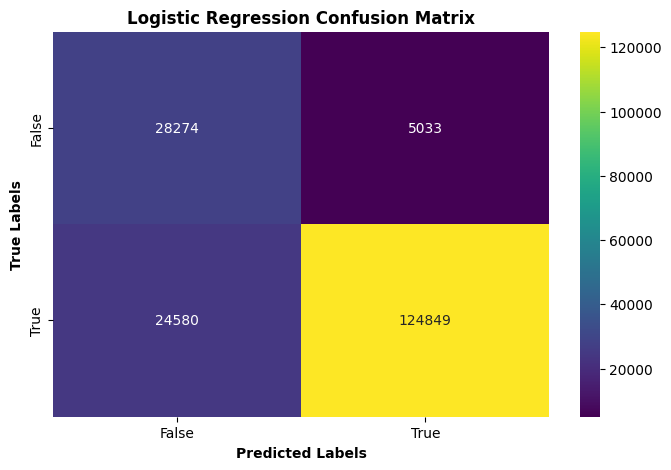

In [57]:
lr_cm = confusion_matrix(y_test, y_pred_logReg)
cls_names = ['False','True']

plt.figure(figsize=(8,5))
plt.title("Logistic Regression Confusion Matrix",weight='bold')
sns.heatmap(lr_cm,annot=True,fmt='d',cmap='viridis',xticklabels=cls_names,yticklabels=cls_names)
plt.xlabel("Predicted Labels", weight="bold")
plt.ylabel("True Labels",weight="bold")
plt.show()

### **G.2 GaussianNB Confusion Matrix**

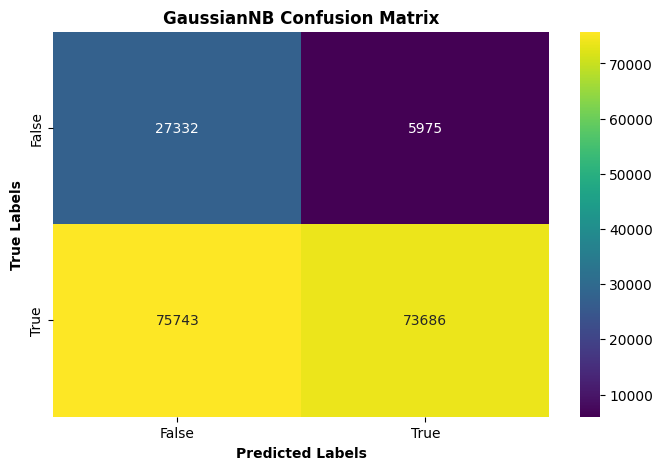

In [58]:
gaussNB_cm = confusion_matrix(y_test, y_pred_gaussNB)
cls_names = ['False','True']

plt.figure(figsize=(8,5))
plt.title("GaussianNB Confusion Matrix",weight='bold')
sns.heatmap(gaussNB_cm,annot=True,fmt='d',cmap='viridis',xticklabels=cls_names,yticklabels=cls_names)
plt.xlabel("Predicted Labels", weight="bold")
plt.ylabel("True Labels",weight="bold")
plt.show()

### **G.3 KNN Confusion Matrix**

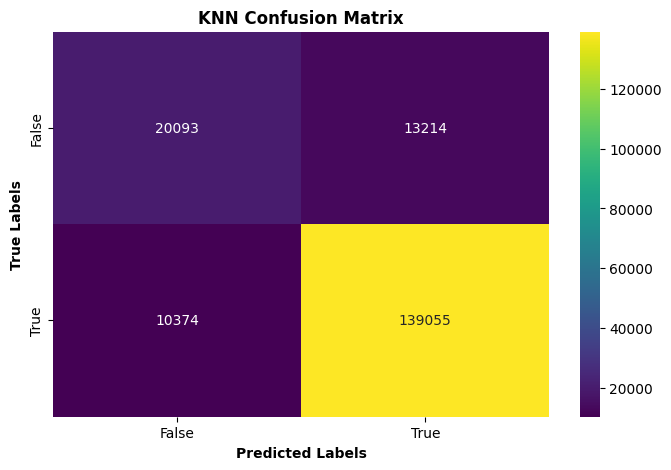

In [59]:
knn_cm = confusion_matrix(y_test, y_pred_knn)
cls_names = ['False','True']

plt.figure(figsize=(8,5))
plt.title("KNN Confusion Matrix",weight='bold')
sns.heatmap(knn_cm,annot=True,fmt='d',cmap='viridis',xticklabels=cls_names,yticklabels=cls_names)
plt.xlabel("Predicted Labels", weight="bold")
plt.ylabel("True Labels",weight="bold")
plt.show()

### **G.4 Decision Tree Confusion Matrix**

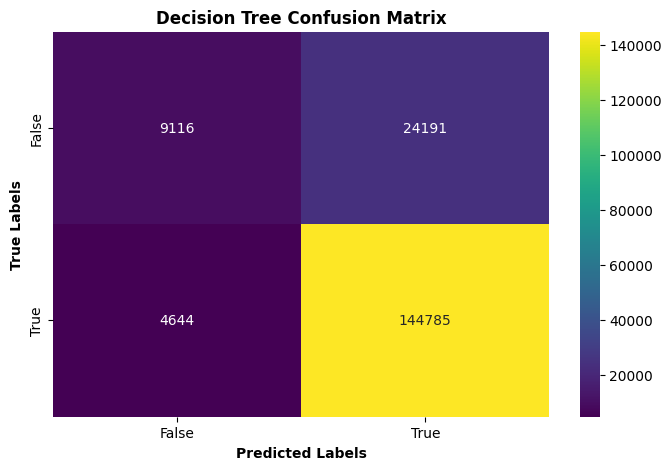

In [60]:
dt_cm = confusion_matrix(y_test, y_pred_dt)
cls_names = ['False','True']

plt.figure(figsize=(8,5))
plt.title("Decision Tree Confusion Matrix",weight='bold')
sns.heatmap(dt_cm,annot=True,fmt='d',cmap='viridis',xticklabels=cls_names,yticklabels=cls_names)
plt.xlabel("Predicted Labels", weight="bold")
plt.ylabel("True Labels",weight="bold")
plt.show()

### **G.5 RandomForest Confusion Matrix**

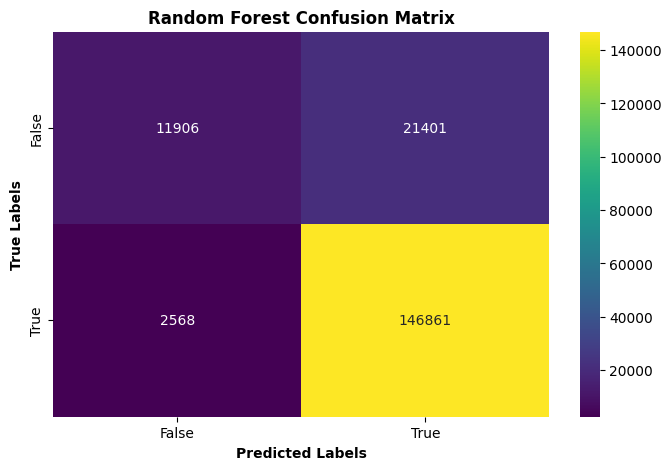

In [61]:
rf_cm = confusion_matrix(y_test, y_pred_rf)
cls_names = ['False','True']

plt.figure(figsize=(8,5))
plt.title("Random Forest Confusion Matrix",weight='bold')
sns.heatmap(rf_cm,annot=True,fmt='d',cmap='viridis',xticklabels=cls_names,yticklabels=cls_names)
plt.xlabel("Predicted Labels", weight="bold")
plt.ylabel("True Labels",weight="bold")
plt.show()

### **G.6 XGBoost Confusion Matrix**

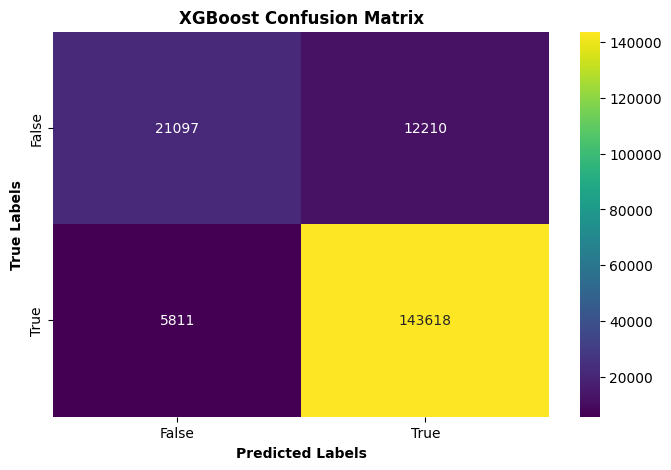

In [62]:
xgb_cm = confusion_matrix(y_test, y_pred_xgb)
cls_names = ['False','True']

plt.figure(figsize=(8,5))
plt.title("XGBoost Confusion Matrix",weight='bold')
sns.heatmap(xgb_cm,annot=True,fmt='d',cmap='viridis',xticklabels=cls_names,yticklabels=cls_names)
plt.xlabel("Predicted Labels", weight="bold")
plt.ylabel("True Labels",weight="bold")
plt.show()

### **G.7 ANN Confusion Matrix**

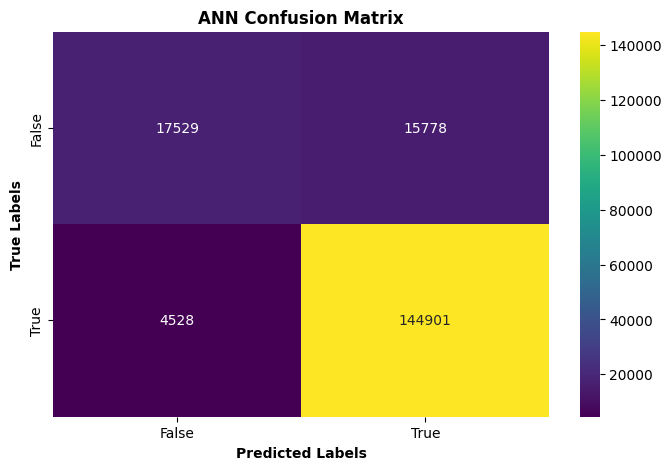

In [63]:
ann_cm = confusion_matrix(y_test, y_pred_ANN)
cls_names = ['False','True']

plt.figure(figsize=(8,5))
plt.title("ANN Confusion Matrix",weight='bold')
sns.heatmap(ann_cm,annot=True,fmt='d',cmap='viridis',xticklabels=cls_names,yticklabels=cls_names)
plt.xlabel("Predicted Labels", weight="bold")
plt.ylabel("True Labels",weight="bold")
plt.show()

# **H. Hyperparameter Tuning for Selected Models**

Based on the above Model evaluation analysis, we will tune only three Models:
1. XGBoost Model (1st Priority Model)
2. AN Model 
3. Logistic Regression Model

### **H.1 Creating Validation split from the Training Data**

In [64]:
X_train_opt, X_val, y_train_opt, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training data:", X_train_opt.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test_scaled.shape)

Training data: (438565, 200)
Validation data: (109642, 200)
Test data: (182736, 200)


### **H.2 Initializing Objective Function**

In [65]:
def objective(trial, model_name):

    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    if model_name == "xgb_model":

        params = {
            "n_estimators": trial.suggest_int("n_estimators",50,300,step=50),
            "max_depth": trial.suggest_int("max_depth",3,9),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3,log=True),
            "subsample": trial.suggest_float("subsample",0.7,1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree",0.7,1.0),
            "min_child_weight": trial.suggest_int("min_child_weight",1,10),
            "eval_metric": "logloss",
            "random_state": 42,
            "n_jobs": 16
        }

        model = XGBClassifier(**params)

        model.fit(X_train_opt,y_train_opt)

        preds = model.predict(X_val)

        # Macro F1 because of 80:20 class imbalance
        score = f1_score(y_val,preds,average="macro")

        return score

    # --------------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------------

    elif model_name == "log_reg_model":

        penalty = trial.suggest_categorical("penalty",["l1", "l2"])
        C = trial.suggest_float("C",1e-4,10.0,log=True)

        model = LogisticRegression(penalty=penalty,C=C,solver="liblinear",max_iter=1000,random_state=42)

        model.fit(X_train_opt,y_train_opt)

        preds = model.predict(X_val)

        score = f1_score(y_val,preds,average="macro")

        return score


    # --------------------------------------------------------
    # ANN
    # --------------------------------------------------------

    elif model_name == "ann_model":

        # Clear previous TensorFlow model from memory
        tf.keras.backend.clear_session()

        units_layer1 = trial.suggest_categorical("units_l1",[32, 64, 128])
        units_layer2 = trial.suggest_categorical("units_l2",[32, 64, 128])
        dropout_rate = trial.suggest_float("dropout",0.1, 0.5,step=0.1)
        learning_rate = trial.suggest_float("learning_rate",1e-4,1e-2,log=True)
        optimizer_choice = trial.suggest_categorical("optimizer",["adam", "sgd"])

        # -----------------------------
        # Build ANN
        # -----------------------------

        ann_model = Sequential()

        ann_model.add(Dense(units_layer1,activation="relu",input_shape=(X_train_opt.shape[1],)))
        ann_model.add(Dropout(dropout_rate))

        ann_model.add(Dense(units_layer2,activation="relu"))
        ann_model.add(Dropout(dropout_rate))

        # Binary classification
        ann_model.add(Dense(2,activation="softmax"))

        if optimizer_choice == "adam":
            optimizer = Adam(
                learning_rate=learning_rate
            )
        else:
            optimizer = SGD(
                learning_rate=learning_rate
            )

        ann_model.compile(optimizer=optimizer,loss="sparse_categorical_crossentropy",metrics=["accuracy"])

        ann_model.fit(X_train_opt,y_train_opt,validation_data=(X_val, y_val),epochs=30,batch_size=32,verbose=0)

        probabilities = ann_model.predict(X_val,verbose=0)

        preds = np.argmax(probabilities,axis=1)

        score = f1_score(y_val,preds,average="macro")

        return score

### **H.3 Running Optuna**

In [66]:
models_to_tune = ["xgb_model","log_reg_model","ann_model"]

best_params = {}
optimization_results = {}

optimizer_start_time = t.time()


for name in models_to_tune:

    print("\n" + "=" * 60)
    print(f"OPTIMIZING: {name.upper()}")
    print("=" * 60)

    study = optuna.create_study(direction="maximize")

    study.optimize(lambda trial: objective(trial, name),n_trials=10)


    # Save results
    best_params[name] = study.best_params
    optimization_results[name] = study.best_value

    print("\nBest Parameters:")
    print(study.best_params)

    print(f"\nBest Validation Macro F1: "f"{study.best_value:.4f}")

optimizer_end_time = t.time()

print("\n" + "=" * 60)
print("TOTAL OPTIMIZATION TIME:",round((optimizer_end_time - optimizer_start_time) / 60,2),"minutes")
print("=" * 60)

[I 2026-08-16 15:30:47,591] A new study created in memory with name: no-name-34967c55-612c-40ff-b135-cbe236e074d7



OPTIMIZING: XGB_MODEL


[I 2026-08-16 15:31:12,994] Trial 0 finished with value: 0.8184643917439612 and parameters: {'n_estimators': 150, 'max_depth': 9, 'learning_rate': 0.19588585525608576, 'subsample': 0.8944996664829834, 'colsample_bytree': 0.9589783274298881, 'min_child_weight': 8}. Best is trial 0 with value: 0.8184643917439612.
[I 2026-08-16 15:31:40,208] Trial 1 finished with value: 0.8058008478731409 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.051829837721453845, 'subsample': 0.8180554311924283, 'colsample_bytree': 0.9735509648640017, 'min_child_weight': 9}. Best is trial 0 with value: 0.8184643917439612.
[I 2026-08-16 15:32:04,387] Trial 2 finished with value: 0.7539002985579799 and parameters: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.018074888077946452, 'subsample': 0.9640641059828915, 'colsample_bytree': 0.8592334531911104, 'min_child_weight': 8}. Best is trial 0 with value: 0.8184643917439612.
[I 2026-08-16 15:32:22,504] Trial 3 finished with value: 0.


Best Parameters:
{'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1007990647162967, 'subsample': 0.982947252924347, 'colsample_bytree': 0.8501947265131407, 'min_child_weight': 5}

Best Validation Macro F1: 0.8215

OPTIMIZING: LOG_REG_MODEL


[I 2026-08-16 15:34:56,692] Trial 0 finished with value: 0.7791721148305799 and parameters: {'penalty': 'l2', 'C': 9.94632352630458}. Best is trial 0 with value: 0.7791721148305799.
[I 2026-08-16 15:35:02,143] Trial 1 finished with value: 0.44986452584044156 and parameters: {'penalty': 'l1', 'C': 0.00038324883904944276}. Best is trial 0 with value: 0.7791721148305799.
[I 2026-08-16 15:44:22,065] Trial 2 finished with value: 0.7775583712487846 and parameters: {'penalty': 'l1', 'C': 0.33127997085205324}. Best is trial 0 with value: 0.7791721148305799.
[I 2026-08-16 15:44:40,500] Trial 3 finished with value: 0.7786960238806782 and parameters: {'penalty': 'l2', 'C': 3.2235913457040932}. Best is trial 0 with value: 0.7791721148305799.
[I 2026-08-16 15:48:37,890] Trial 4 finished with value: 0.7415228328307193 and parameters: {'penalty': 'l1', 'C': 0.013905848215543522}. Best is trial 0 with value: 0.7791721148305799.
[I 2026-08-16 15:55:16,615] Trial 5 finished with value: 0.769745094986674


Best Parameters:
{'penalty': 'l2', 'C': 9.94632352630458}

Best Validation Macro F1: 0.7792

OPTIMIZING: ANN_MODEL



[I 2026-08-16 16:02:04,741] Trial 0 finished with value: 0.7556952628852369 and parameters: {'units_l1': 32, 'units_l2': 64, 'dropout': 0.30000000000000004, 'learning_rate': 0.0004298704045913225, 'optimizer': 'sgd'}. Best is trial 0 with value: 0.7556952628852369.
[I 2026-08-16 16:08:50,667] Trial 1 finished with value: 0.44986452584044156 and parameters: {'units_l1': 32, 'units_l2': 64, 'dropout': 0.4, 'learning_rate': 0.009152905268497434, 'optimizer': 'adam'}. Best is trial 0 with value: 0.7556952628852369.
[I 2026-08-16 16:15:23,571] Trial 2 finished with value: 0.44986452584044156 and parameters: {'units_l1': 32, 'units_l2': 64, 'dropout': 0.2, 'learning_rate': 0.007971610863284127, 'optimizer': 'adam'}. Best is trial 0 with value: 0.7556952628852369.
[I 2026-08-16 16:21:44,876] Trial 3 finished with value: 0.44986452584044156 and parameters: {'units_l1': 64, 'units_l2': 64, 'dropout': 0.30000000000000004, 'learning_rate': 0.00012255213839469455, 'optimizer': 'sgd'}. Best is tria


Best Parameters:
{'units_l1': 32, 'units_l2': 128, 'dropout': 0.2, 'learning_rate': 0.009761997276746977, 'optimizer': 'sgd'}

Best Validation Macro F1: 0.8147

TOTAL OPTIMIZATION TIME: 91.27 minutes


### **H.4 View All Best Paramters**

In [67]:
for model_name, params in best_params.items():
    print("\n", model_name.upper())
    print("-" * 40)

    for parameter, value in params.items():
        print(f"{parameter}: {value}")


 XGB_MODEL
----------------------------------------
n_estimators: 300
max_depth: 9
learning_rate: 0.1007990647162967
subsample: 0.982947252924347
colsample_bytree: 0.8501947265131407
min_child_weight: 5

 LOG_REG_MODEL
----------------------------------------
penalty: l2
C: 9.94632352630458

 ANN_MODEL
----------------------------------------
units_l1: 32
units_l2: 128
dropout: 0.2
learning_rate: 0.009761997276746977
optimizer: sgd


### **H.5 hyperparameter Tuning Results**

#### **XGB_MODEL**
----------------------------------------
n_estimators: 300  
max_depth: 9  
learning_rate: 0.1007990647162967  
subsample: 0.982947252924347  
colsample_bytree: 0.8501947265131407  
min_child_weight: 5  

 #### **LOG_REG_MODEL**
----------------------------------------
penalty: l2  
C: 9.94632352630458

 #### **ANN_MODEL**
----------------------------------------
units_l1: 32  
units_l2: 128  
dropout: 0.2  
learning_rate: 0.009761997276746977  
optimizer: sgd  

# **I. Final Optimized Models**

### **I.1 Optimized XGBoost Model**

In [68]:
import xgboost as xgb

opt_xgb_model = xgb.XGBClassifier(n_estimators=300,
                                  max_depth=9,
                                  learning_rate=0.1,
                                  subsample=0.98,
                                  colsample_bytree=0.85,
                                  min_child_weight=5)

opt_xgb_model.fit(X_train_scaled,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [69]:
y_pred_opt_xgb = opt_xgb_model.predict(X_test_scaled)

print("Classification Report for Optimized XGBoost Model:\n",classification_report(y_test,y_pred_opt_xgb))

Classification Report for Optimized XGBoost Model:
               precision    recall  f1-score   support

       False       0.79      0.64      0.71     33307
        True       0.92      0.96      0.94    149429

    accuracy                           0.90    182736
   macro avg       0.86      0.80      0.83    182736
weighted avg       0.90      0.90      0.90    182736



### **I.2 Optimized Logistic Regression Model**

In [70]:
opt_lr_model = LogisticRegression(penalty='l2',
                                  C=9.94)

opt_lr_model.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",9.94
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver bec

In [71]:
y_pred_opt_lr = opt_lr_model.predict(X_test_scaled)


print("Classification Report for Optimized Logistic Regression Model:\n",classification_report(y_test,y_pred_opt_lr))

Classification Report for Optimized Logistic Regression Model:
               precision    recall  f1-score   support

       False       0.75      0.53      0.62     33307
        True       0.90      0.96      0.93    149429

    accuracy                           0.88    182736
   macro avg       0.82      0.74      0.77    182736
weighted avg       0.87      0.88      0.87    182736



### **I.3 Optimized ANN model**

In [72]:
opt_ann_model = Sequential()

# Input Layer
opt_ann_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
opt_ann_model.add(Dropout(0.2))

opt_ann_model.add(Dense(128,activation="relu"))

opt_ann_model.add(Dropout(0.2))

# Output Layer
opt_ann_model.add(Dense(2,activation="softmax"))

# SGD Optimizer
optimizer = SGD(learning_rate=0.009761997276746977)

# Compile
opt_ann_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model summary
opt_ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,914 (42.63 KB)

 Trainable params: 10,914 (42.63 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
history_tuned = opt_ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - accuracy: 0.8622 - loss: 0.3198 - val_accuracy: 0.4145 - val_loss: 0.8174
Epoch 2/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8678 - loss: 0.3081 - val_accuracy: 0.8652 - val_loss: 0.3180
Epoch 3/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8712 - loss: 0.3005 - val_accuracy: 0.8355 - val_loss: 0.4237
Epoch 4/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.8736 - loss: 0.2955 - val_accuracy: 0.8730 - val_loss: 0.2891
Epoch 5/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step - accuracy: 0.8753 - loss: 0.2921 - val_accuracy: 0.8547 - val_loss: 0.3635
Epoch 6/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8771 - loss: 0.2887 - val_accuracy: 0.8861 - val_loss: 0.2670
Epoch 7/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.8781 - loss: 0.2872 - val_accuracy: 0.7527 - val_loss: 0.4522
Epoch 8/30
13706/13706 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - accuracy: 

In [76]:
ann_probabilities = opt_ann_model.predict(
    X_test_scaled,
    verbose=0
)

y_pred_ANN_tuned = np.argmax(
    ann_probabilities,
    axis=1
)


print("Tuned ANN Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_ANN_tuned
    )
)

Tuned ANN Classification Report:

              precision    recall  f1-score   support

       False       0.90      0.15      0.26     33307
        True       0.84      1.00      0.91    149429

    accuracy                           0.84    182736
   macro avg       0.87      0.57      0.59    182736
weighted avg       0.85      0.84      0.79    182736



#### **Hyperparamter Tuning Summary**

- Optuna was used for hyperparameter optimization.
- `XGBoost`, `Logistic Regression`, and `ANN` were selected for tuning based on their base-model performance.
- A separate validation set was used during tuning to avoid test-data leakage.
- Macro F1-score was used as the optimization metric because of the 80:20 class imbalance.
- 10 trials were performed for each selected model.
- The best hyperparameters were used to build the final tuned models.
- Logistic Regression showed improvement after tuning.
- ANN showed poor results after tuning.
- XGBoost remained the best-performing model even after tuning.

Therefore, `XGBoost` was selected as the final model for sentiment classification.

# **J. Final Summary of this Notebook**

- The project developed an NLP-based sentiment analysis system to classify Steam game reviews as positive (True) or negative (False) using Word2Vec-based features and multiple ML models along with an ANN.
- The dataset contained 730,945 reviews and 11 columns. EDA showed that the target variable was imbalanced, with 81.77% positive and 18.23% negative reviews.
- Data cleaning included handling the completely missing release_date column and removing duplicate records.
- EDA showed that most reviews were short, with fewer than 50 words, while a small number of reviews were much longer. The character-length distribution was also highly right-skewed.
- Text preprocessing was performed before converting reviews into numerical representations using Word2Vec.
- Multiple classification models were trained and compared using Accuracy, minority-class Precision/Recall, Macro F1-score, and Training Time.
- Among the base models, `XGBoost` achieved the best overall performance, with approximately 90% accuracy and 0.82 Macro F1-score.
- Logistic Regression achieved the highest recall for the minority negative class, making it effective at identifying negative reviews, although its precision for that class was lower.
- ANN achieved strong performance, but its minority-class recall was lower than that of Logistic Regression and XGBoost.
- Hyperparameter tuning was performed using Optuna on XGBoost, ANN, and Logistic Regression, using a separate validation set and Macro F1-score as the optimization metric because of class imbalance.
- Tuning improved Logistic Regression, while the tuned ANN did not outperform the strongest models. `XGBoost` remained the best-performing model after tuning.

Therefore, `XGBoost` was selected as the final model because it provided the best overall balance between accuracy and performance across the two sentiment classes.

# **K. Final Model and Vectorizer Export**

In [84]:
import joblib

joblib.dump(
    opt_xgb_model,
    "./Final_model/xgb_model.pkl"
)

w2v_model.save(
    "./Final_model/word2vec.model"
)

joblib.dump(
    scaler,
    "./Final_model/scaler.pkl"
)

['./Final_model/scaler.pkl']